In [2]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    train_test_split, cross_val_score, GroupKFold,
)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")

### Data inladen 

In [3]:
df_env = pd.read_csv("Data/Diversity_data_with_env.csv")
df_env = df_env[["long_deg", "lat_deg", "DepthMean", "LandDist", "Shelf", "Slope", "Abyssal", "Seamount"]]

print(f"env data:             {df_env.shape}")
df_env.head()

env data:             (2452, 8)


,long_deg,lat_deg,DepthMean,LandDist,Shelf,Slope,Abyssal,Seamount
0,-171.74579,-71.23536,3998,636,0.0,730.228795,263.361205,0
1,-167.88679,-71.23536,4079,742,0.0,0.000000,993.590000,0
2,-164.02779,-71.23536,4185,708,0.0,0.000000,993.590000,0
3,-160.16879,-71.23536,4231,661,0.0,0.000000,993.590000,0
4,-156.30979,-71.23536,4322,608,0.0,0.000000,993.590000,0


In [4]:
df_biooracle = pd.read_csv("Data/Diversity_data_with_biooracle_2010.csv")
print(f"biooracle data:       {df_biooracle.shape}")
df_biooracle.head()

biooracle data:       (2452, 75)


,marine_species_richness,PD,co1_genetic_diversity_mean,long_deg,lat_deg,chl_max,chl_mean,chl_min,clt_max,clt_mean,...,terrain_characteristics_bea_min,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_ltmax,T_ltmin,T_max,T_mean,T_min,T_range
0,44,11.830844,0.007171,-171.74579,-71.23536,1.987486,0.264222,0.015311,0.993542,0.681597,...,-3883.0,66.347260,0.933108,6.854279,-0.711044,-1.904281,-0.127859,-1.602750,-1.977225,1.849366
1,43,11.830844,0.007171,-167.88679,-71.23536,2.205368,0.278952,0.015232,0.961121,0.693978,...,-4084.0,21.055542,0.320794,-12.930603,-0.847708,-1.925544,-0.017505,-1.620118,-2.000000,1.988636
2,44,12.650381,0.007499,-164.02779,-71.23536,1.891105,0.270836,0.015052,0.960210,0.698352,...,-4153.0,14.489563,0.228825,5.524109,-0.521772,-1.923338,0.125601,-1.582915,-2.000000,2.137620
3,44,12.650381,0.007499,-160.16879,-71.23536,1.963815,0.293940,0.015424,0.962838,0.693123,...,-4303.0,4.413208,0.081748,1.760254,-0.558407,-1.909406,-0.032617,-1.579760,-1.976150,1.943533
4,45,12.650381,0.007499,-156.30979,-71.23536,1.956123,0.298378,0.015726,0.969080,0.688964,...,-4341.0,10.302124,0.234018,-0.892456,-0.570859,-1.906482,-0.000029,-1.570748,-2.000000,2.001978


### Variabelen bekijken

In [5]:
df_biooracle.columns

Index(['marine_species_richness', 'PD', 'co1_genetic_diversity_mean',
       'long_deg', 'lat_deg', 'chl_max', 'chl_mean', 'chl_min', 'clt_max',
       'clt_mean', 'clt_min', 'currentdirection_max', 'currentdirection_mean',
       'currentdirection_min', 'currentvelocity_ltmax', 'currentvelocity_max',
       'currentvelocity_mean', 'currentvelocity_min', 'dfe_max', 'dfe_mean',
       'dfe_min', 'kdpar_max', 'kdpar_mean', 'kdpar_min', 'mlotst_max',
       'mlotst_mean', 'mlotst_min', 'no3_max', 'no3_mean', 'no3_min', 'o2_max',
       'o2_mean', 'o2_min', 'par_mean', 'par_min', 'phyc_max', 'phyc_mean',
       'phyc_min', 'ph_max', 'ph_mean', 'ph_min', 'po4_max', 'po4_mean',
       'po4_min', 'salinity_ltmax', 'salinity_ltmin', 'salinity_max',
       'salinity_mean', 'salinity_min', 'salinity_range', 'siconc_max',
       'siconc_mean', 'siconc_min', 'sithick_max', 'sithick_mean',
       'sithick_min', 'si_max', 'si_mean', 'si_min', 'tas_max', 'tas_mean',
       'tas_min', 'terrain_charact

In [6]:
df_env.columns

Index(['long_deg', 'lat_deg', 'DepthMean', 'LandDist', 'Shelf', 'Slope',
       'Abyssal', 'Seamount'],
      dtype='object')

### Beide datasets samenvoegen obv locatie (longitude en latitude)


In [7]:
df_merge = pd.merge(df_env, df_biooracle, on = ["long_deg", "lat_deg"], how = "inner")
print(f"merged data:             {df_merge.shape}")
df_merge.head()

merged data:             (2452, 81)


,long_deg,lat_deg,DepthMean,LandDist,Shelf,Slope,Abyssal,Seamount,marine_species_richness,PD,...,terrain_characteristics_bea_min,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_ltmax,T_ltmin,T_max,T_mean,T_min,T_range
0,-171.74579,-71.23536,3998,636,0.0,730.228795,263.361205,0,44,11.830844,...,-3883.0,66.347260,0.933108,6.854279,-0.711044,-1.904281,-0.127859,-1.602750,-1.977225,1.849366
1,-167.88679,-71.23536,4079,742,0.0,0.000000,993.590000,0,43,11.830844,...,-4084.0,21.055542,0.320794,-12.930603,-0.847708,-1.925544,-0.017505,-1.620118,-2.000000,1.988636
2,-164.02779,-71.23536,4185,708,0.0,0.000000,993.590000,0,44,12.650381,...,-4153.0,14.489563,0.228825,5.524109,-0.521772,-1.923338,0.125601,-1.582915,-2.000000,2.137620
3,-160.16879,-71.23536,4231,661,0.0,0.000000,993.590000,0,44,12.650381,...,-4303.0,4.413208,0.081748,1.760254,-0.558407,-1.909406,-0.032617,-1.579760,-1.976150,1.943533
4,-156.30979,-71.23536,4322,608,0.0,0.000000,993.590000,0,45,12.650381,...,-4341.0,10.302124,0.234018,-0.892456,-0.570859,-1.906482,-0.000029,-1.570748,-2.000000,2.001978


In [8]:
df_merge.columns

Index(['long_deg', 'lat_deg', 'DepthMean', 'LandDist', 'Shelf', 'Slope',
       'Abyssal', 'Seamount', 'marine_species_richness', 'PD',
       'co1_genetic_diversity_mean', 'chl_max', 'chl_mean', 'chl_min',
       'clt_max', 'clt_mean', 'clt_min', 'currentdirection_max',
       'currentdirection_mean', 'currentdirection_min',
       'currentvelocity_ltmax', 'currentvelocity_max', 'currentvelocity_mean',
       'currentvelocity_min', 'dfe_max', 'dfe_mean', 'dfe_min', 'kdpar_max',
       'kdpar_mean', 'kdpar_min', 'mlotst_max', 'mlotst_mean', 'mlotst_min',
       'no3_max', 'no3_mean', 'no3_min', 'o2_max', 'o2_mean', 'o2_min',
       'par_mean', 'par_min', 'phyc_max', 'phyc_mean', 'phyc_min', 'ph_max',
       'ph_mean', 'ph_min', 'po4_max', 'po4_mean', 'po4_min', 'salinity_ltmax',
       'salinity_ltmin', 'salinity_max', 'salinity_mean', 'salinity_min',
       'salinity_range', 'siconc_max', 'siconc_mean', 'siconc_min',
       'sithick_max', 'sithick_mean', 'sithick_min', 'si_max', 'si_m

 data verwijderen die onnodig is: meerdere keren coördinaten, andere biodiversiteitsmaten, enkel gemiddeldes overhouden

In [9]:
cols_to_drop = (df_merge.filter(regex=r'(?i)(min|max|range)').columns.tolist() + ["PD", "marine_species_richness"])
df_merge = df_merge.drop(cols_to_drop, axis = 1)

### Dubbele kolommen verwijderen

In [10]:
df_merge = df_merge.T.drop_duplicates().T

df_merge.head()

,long_deg,lat_deg,DepthMean,LandDist,Shelf,Slope,Abyssal,Seamount,co1_genetic_diversity_mean,chl_mean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
0,-171.74579,-71.23536,3998.0,636.0,0.0,730.228795,263.361205,0.0,0.007171,0.264222,...,0.731921,0.682407,103.700478,-12.067131,10.920937,-3936.972168,66.347260,0.933108,6.854279,-1.602750
1,-167.88679,-71.23536,4079.0,742.0,0.0,0.000000,993.590000,0.0,0.007171,0.278952,...,0.727964,0.742742,104.054313,-11.786772,141.201179,-4093.388916,21.055542,0.320794,-12.930603,-1.620118
2,-164.02779,-71.23536,4185.0,708.0,0.0,0.000000,993.590000,0.0,0.007499,0.270836,...,0.693648,0.713952,102.867443,-11.387081,216.269828,-4160.611328,14.489563,0.228825,5.524109,-1.582915
3,-160.16879,-71.23536,4231.0,661.0,0.0,0.000000,993.590000,0.0,0.007499,0.293940,...,0.693803,0.720227,99.723148,-10.962065,224.836870,-4305.361328,4.413208,0.081748,1.760254,-1.579760
4,-156.30979,-71.23536,4322.0,608.0,0.0,0.000000,993.590000,0.0,0.007499,0.298378,...,0.687315,0.703112,97.156055,-10.534314,300.267603,-4353.527832,10.302124,0.234018,-0.892456,-1.570748


In [11]:
df_merge.columns

Index(['long_deg', 'lat_deg', 'DepthMean', 'LandDist', 'Shelf', 'Slope',
       'Abyssal', 'Seamount', 'co1_genetic_diversity_mean', 'chl_mean',
       'clt_mean', 'currentdirection_mean', 'currentvelocity_mean', 'dfe_mean',
       'kdpar_mean', 'mlotst_mean', 'no3_mean', 'o2_mean', 'par_mean',
       'phyc_mean', 'ph_mean', 'po4_mean', 'salinity_mean', 'siconc_mean',
       'sithick_mean', 'si_mean', 'tas_mean', 'terrain_characteristics_aspect',
       'terrain_characteristics_bea_mean', 'terrain_characteristics_rug',
       'terrain_characteristics_slope', 'terrain_characteristics_topo',
       'T_mean'],
      dtype='object')

# Data exploratie

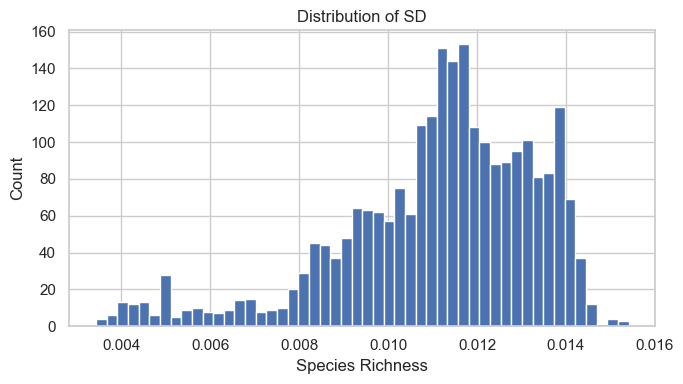

In [12]:
target = "co1_genetic_diversity_mean"
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_merge[target], bins=50, edgecolor="white")
ax.set_xlabel("Species Richness")
ax.set_ylabel("Count")
ax.set_title("Distribution of SD")
plt.tight_layout()
plt.show()

## Correlatie berekenen
Variabelen t.o.v. target

In [13]:
corr_to_target = df_merge.corr(method = "pearson")[target].drop(labels = [target]) #correlatie berekenen van alle variabelen tov target en correlatie target met zichzelf laten vallen (is toch gelijk aan 1)
top = corr_to_target.reindex(corr_to_target.abs().sort_values(ascending=False).index) #sorteer van hoog naar laag
top.head(10)

tas_mean        0.828179
o2_mean        -0.801597
T_mean          0.796517
clt_mean       -0.690056
par_mean        0.664754
po4_mean       -0.646589
siconc_mean    -0.641711
sithick_mean   -0.639092
no3_mean       -0.619374
si_mean        -0.574536
Name: co1_genetic_diversity_mean, dtype: float64

variabelen t.o.v. elkaar

In [14]:
corr = df_merge.corr(numeric_only=True)

# corr omzetten naar lijst van paren
corr_pairs = corr.abs().unstack()

# zelf-correlaties verwijderen
corr_pairs = corr_pairs[corr_pairs < 1]

# top 10
top_pairs = corr_pairs.sort_values(ascending=False).drop_duplicates().head(10)

print(top_pairs)

T_mean                            tas_mean                       0.988904
o2_mean                           T_mean                         0.984634
po4_mean                          no3_mean                       0.978716
terrain_characteristics_bea_mean  DepthMean                      0.978477
tas_mean                          o2_mean                        0.973124
siconc_mean                       sithick_mean                   0.967492
terrain_characteristics_slope     terrain_characteristics_rug    0.940959
phyc_mean                         chl_mean                       0.938889
T_mean                            clt_mean                       0.879003
po4_mean                          T_mean                         0.863900
dtype: float64


### Onnodige kolommen verwijderen

### Target en variabelen selecteren

In [15]:
target = "co1_genetic_diversity_mean" # Geselecteerde biodiversiteitsmaat om te voorspellen.
feature_cols = df_merge.columns.drop(["long_deg", "lat_deg", target]).tolist()

print(feature_cols)

['DepthMean', 'LandDist', 'Shelf', 'Slope', 'Abyssal', 'Seamount', 'chl_mean', 'clt_mean', 'currentdirection_mean', 'currentvelocity_mean', 'dfe_mean', 'kdpar_mean', 'mlotst_mean', 'no3_mean', 'o2_mean', 'par_mean', 'phyc_mean', 'ph_mean', 'po4_mean', 'salinity_mean', 'siconc_mean', 'sithick_mean', 'si_mean', 'tas_mean', 'terrain_characteristics_aspect', 'terrain_characteristics_bea_mean', 'terrain_characteristics_rug', 'terrain_characteristics_slope', 'terrain_characteristics_topo', 'T_mean']


In [16]:
df_model = df_merge[[target] + feature_cols].copy()
print(f"Shape before cleaning: {df_model.shape}")
df_model.describe()

Shape before cleaning: (2452, 31)


,co1_genetic_diversity_mean,DepthMean,LandDist,Shelf,Slope,Abyssal,Seamount,chl_mean,clt_mean,currentdirection_mean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
count,2452.000000,2452.000000,2452.000000,2452.000000,2452.000000,2452.000000,2452.000000,2217.000000,2217.000000,2217.000000,...,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2.217000e+03,2217.000000,2217.000000
mean,0.011101,3395.364192,644.398042,106.702485,907.614120,1149.016243,0.092577,0.259398,0.447101,152.689401,...,0.059461,0.070197,14.698095,14.624145,183.500427,-3748.862966,94.427332,1.179893e+00,-2.727722,16.382824
std,0.002254,1807.135985,541.423334,418.417273,1081.733066,1189.317748,0.411971,0.215264,0.186835,80.485733,...,0.173575,0.215610,26.476457,11.465120,104.334155,1538.097895,106.862539,1.406274e+00,76.048905,10.565343
min,0.003430,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.043151,0.027449,8.444567,...,0.000000,0.000000,0.656868,-16.241398,0.182399,-7138.611328,0.000000,2.484808e-17,-658.309052,-1.838033
25%,0.009949,2556.000000,204.000000,0.000000,0.000000,0.000000,0.000000,0.105136,0.271776,74.841409,...,0.000000,0.000000,1.594731,5.300397,93.788117,-4841.555664,30.402771,3.307500e-01,-28.128448,6.396754
50%,0.011438,3944.000000,525.500000,0.000000,135.741786,842.324758,0.000000,0.244400,0.450085,138.466769,...,0.000000,0.000000,2.670603,17.737980,184.875910,-4115.527832,62.715210,7.419182e-01,-1.149323,19.306662
75%,0.012741,4753.250000,987.250000,0.000000,1840.672129,2359.201000,0.000000,0.346993,0.613930,233.689689,...,0.000000,0.000000,13.881882,25.288107,274.005903,-3187.027832,117.663208,1.471722e+00,19.500183,26.387225
max,0.015409,7660.000000,2632.000000,3088.682000,3089.624000,3089.624000,8.000000,3.750575,0.785068,315.692114,...,0.963429,1.794409,121.972284,28.490869,359.858364,0.000000,1098.482654,1.466965e+01,748.565994,30.261832


### Ontbrekende waarden verwijderen

In [17]:
df_model.replace(-9999.0, np.nan, inplace=True)
df_model.replace(-9999, np.nan, inplace=True)

missing = df_model.isna().sum()
print("Missende waarden per kolom:\n")
print(missing[missing > 0])

df_model.dropna(inplace=True)
print(f"\nShape after dropping rows with NaN: {df_model.shape}")

Missende waarden per kolom:

chl_mean                            235
clt_mean                            235
currentdirection_mean               235
currentvelocity_mean                235
dfe_mean                            235
kdpar_mean                          237
mlotst_mean                         235
no3_mean                            235
o2_mean                             235
par_mean                            250
phyc_mean                           235
ph_mean                             235
po4_mean                            235
salinity_mean                       235
siconc_mean                         235
sithick_mean                        235
si_mean                             235
tas_mean                            235
terrain_characteristics_aspect      235
terrain_characteristics_bea_mean    235
terrain_characteristics_rug         235
terrain_characteristics_slope       235
terrain_characteristics_topo        235
T_mean                              235
dtype: int6

### Data splitten in training en test set

In [18]:
X = df_model[feature_cols]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 2026
)

print(f"Training set: {X_train.shape[0]}")
print(f"Test set: {X_test.shape[0]}")

Training set: 1760
Test set: 441


# Fitten van een Random Forest model op training set

In [19]:
rf = RandomForestRegressor(
    n_estimators=800,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=1,
)
rf.fit(X_train, y_train)

,n_estimators,800
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Hyperparameters optimaliseren

### code momenteel als markdown 

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 500, 800],
    "max_depth": [10, 20, 30, None],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", 0.3, 0.5]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 800}

### Evalueren van rf op training en test set

Moet op beide goed zijn anders is het overgefit op training set

In [20]:
y_pred = rf.predict(X_test)

r2_train = rf.score(X_train, y_train)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Train R²: {r2_train:.4f}")
print(f"Test R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"\nTrain-test gap: {r2_train - r2:.4f}")

Train R²: 0.9879
Test R²: 0.9202
RMSE: 0.0006
MAE: 0.0004

Train-test gap: 0.0677


## Visualiseren resultaten

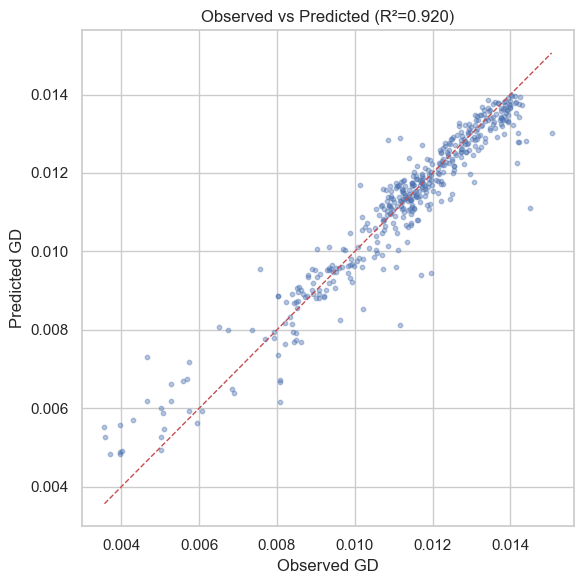

In [21]:
fig, ax = plt.subplots(figsize = (6,6))
ax.scatter(y_test, y_pred, alpha=0.4, s = 10)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--' , linewidth=1)
ax.set_xlabel("Observed GD")
ax.set_ylabel("Predicted GD")
ax.set_title(f"Observed vs Predicted (R²={r2:.3f})")
plt.tight_layout()
plt.show()

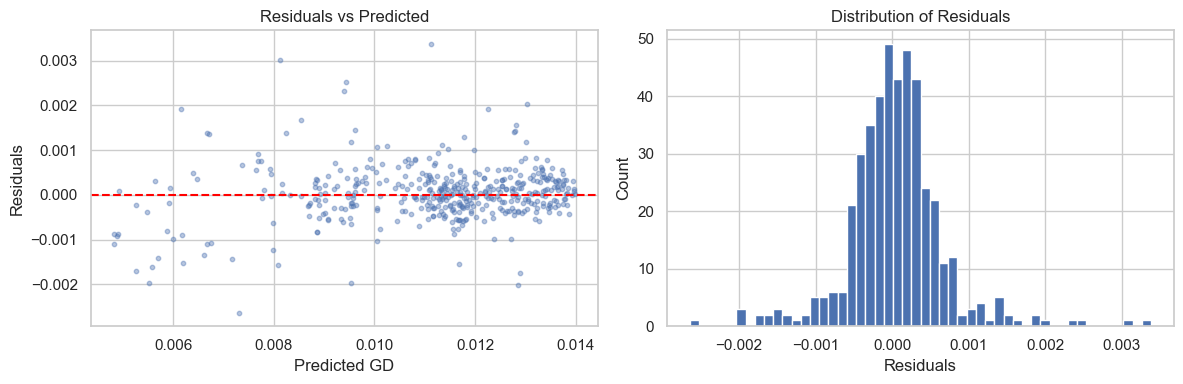

In [22]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1,2, figsize = (12,4))

axes[0].scatter(y_pred, residuals, alpha=0.4, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Predicted GD")
axes[0].set_ylabel("Residuals") 
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=50, edgecolor='white')
axes[1].set_xlabel("Residuals") 
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.show()

### Feature importances van gefitte rf

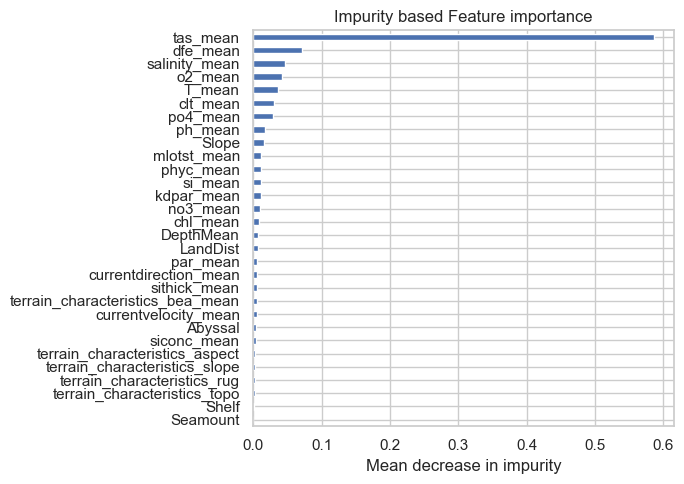

In [23]:
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7,5))
imp.plot.barh(ax=ax)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Impurity based Feature importance")
plt.tight_layout()
plt.show()

### Spatiale crossvalidatie

In [24]:
lat = df_merge.loc[df_model.index, "lat_deg"]
lon = df_merge.loc[df_model.index, "long_deg"]
lat_bin = pd.cut(lat, bins = np.arange(-90, 91,10), labels = False)
lon_bin = pd.cut(lon, bins = np.arange(-180, 181,10), labels = False)
spatial_blocks = lat_bin.astype(str) + "_" + lon_bin.astype(str)

print(f"\nSpatial blocks (10°x10° grid): {spatial_blocks.nunique()} unique blocks")

gkf = GroupKFold(n_splits=5)
spatial_cv = cross_val_score(
    rf, X, y, cv = gkf, groups = spatial_blocks, scoring= "r2", n_jobs = 1,
)
print("Spatial 5 fold VC R² scores:", np.round(spatial_cv, 4))
print(f"Mean R²: {spatial_cv.mean():.4f} ± {spatial_cv.std():.4f}")


Spatial blocks (10°x10° grid): 422 unique blocks
Spatial 5 fold VC R² scores: [0.908  0.9111 0.8958 0.8598 0.8718]
Mean R²: 0.8893 ± 0.0202


# Model met minder variabelen

Dimensionaliteit reduceren
--> uitkijken voor bias

In [25]:
target_red = "co1_genetic_diversity_mean" # Geselecteerde biodiversiteitsmaat om te voorspellen.
feature_cols_red = df_merge.columns.drop(["long_deg", "lat_deg", "co1_genetic_diversity_mean"]).tolist()

df_red = df_merge[[target_red] + feature_cols_red].copy()
print(f"Shape before cleaning: {df_red.shape}")
df_red.describe()

Shape before cleaning: (2452, 31)


,co1_genetic_diversity_mean,DepthMean,LandDist,Shelf,Slope,Abyssal,Seamount,chl_mean,clt_mean,currentdirection_mean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
count,2452.000000,2452.000000,2452.000000,2452.000000,2452.000000,2452.000000,2452.000000,2217.000000,2217.000000,2217.000000,...,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2.217000e+03,2217.000000,2217.000000
mean,0.011101,3395.364192,644.398042,106.702485,907.614120,1149.016243,0.092577,0.259398,0.447101,152.689401,...,0.059461,0.070197,14.698095,14.624145,183.500427,-3748.862966,94.427332,1.179893e+00,-2.727722,16.382824
std,0.002254,1807.135985,541.423334,418.417273,1081.733066,1189.317748,0.411971,0.215264,0.186835,80.485733,...,0.173575,0.215610,26.476457,11.465120,104.334155,1538.097895,106.862539,1.406274e+00,76.048905,10.565343
min,0.003430,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.043151,0.027449,8.444567,...,0.000000,0.000000,0.656868,-16.241398,0.182399,-7138.611328,0.000000,2.484808e-17,-658.309052,-1.838033
25%,0.009949,2556.000000,204.000000,0.000000,0.000000,0.000000,0.000000,0.105136,0.271776,74.841409,...,0.000000,0.000000,1.594731,5.300397,93.788117,-4841.555664,30.402771,3.307500e-01,-28.128448,6.396754
50%,0.011438,3944.000000,525.500000,0.000000,135.741786,842.324758,0.000000,0.244400,0.450085,138.466769,...,0.000000,0.000000,2.670603,17.737980,184.875910,-4115.527832,62.715210,7.419182e-01,-1.149323,19.306662
75%,0.012741,4753.250000,987.250000,0.000000,1840.672129,2359.201000,0.000000,0.346993,0.613930,233.689689,...,0.000000,0.000000,13.881882,25.288107,274.005903,-3187.027832,117.663208,1.471722e+00,19.500183,26.387225
max,0.015409,7660.000000,2632.000000,3088.682000,3089.624000,3089.624000,8.000000,3.750575,0.785068,315.692114,...,0.963429,1.794409,121.972284,28.490869,359.858364,0.000000,1098.482654,1.466965e+01,748.565994,30.261832


Hier nog eens opnieuw de missende waarden verwijderen, want df is weer gemaakt op basis van de kolommen waar die waarden nog niet waren verwijderd. 

In [26]:
df_red.replace(-9999.0, np.nan, inplace=True)
df_red.replace(-9999, np.nan, inplace=True)

missing = df_red.isna().sum()
print("Missende waarden per kolom:\n")
print(missing[missing > 0])

df_red.dropna(inplace=True)
print(f"\nShape after dropping rows with NaN: {df_red.shape}")

Missende waarden per kolom:

chl_mean                            235
clt_mean                            235
currentdirection_mean               235
currentvelocity_mean                235
dfe_mean                            235
kdpar_mean                          237
mlotst_mean                         235
no3_mean                            235
o2_mean                             235
par_mean                            250
phyc_mean                           235
ph_mean                             235
po4_mean                            235
salinity_mean                       235
siconc_mean                         235
sithick_mean                        235
si_mean                             235
tas_mean                            235
terrain_characteristics_aspect      235
terrain_characteristics_bea_mean    235
terrain_characteristics_rug         235
terrain_characteristics_slope       235
terrain_characteristics_topo        235
T_mean                              235
dtype: int6

In [27]:
print(X.isna().sum().sort_values(ascending=False).head(10))

DepthMean                           0
LandDist                            0
terrain_characteristics_topo        0
terrain_characteristics_slope       0
terrain_characteristics_rug         0
terrain_characteristics_bea_mean    0
terrain_characteristics_aspect      0
tas_mean                            0
si_mean                             0
sithick_mean                        0
dtype: int64


In [28]:
X_red = df_red[feature_cols_red]
y_red = df_red[target_red]

## Recursive feature elimination 
### RMSE en spatiale cross validatie

Als markdown

from sklearn.feature_selection import RFECV

#### Random Forest
estimator = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

#### RFECV met spatial CV + RMSE
selector = RFECV(
    estimator,
    step=1,
    cv=gkf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

selector.fit(X_red, y_red, groups=spatial_blocks)

print(f"Optimal number of features: {selector.n_features_}")

selected_features_RFECV = X.columns[selector.support_]
print("Selected features:", list(selected_features_RFECV))

## dataset met geselecteerde features

In [29]:
selected_features_RFECV = [ # Dit zijn de variabelen die we hier selecteren om de biodiversiteit te voorspellen.
    "chl_mean",      # variabelen kiezen die invloed gaan hebben op de biodiversiteit  
    "clt_mean",  
    "dfe_mean",      
    "kdpar_mean",
    "mlotst_mean",
    "no3_mean",
    "o2_mean",
    "par_mean",
    "phyc_mean",
    "ph_mean",
    "po4_mean",
    "salinity_mean",
    "si_mean",
    "sithick_mean",
    "tas_mean",
    "terrain_characteristics_bea_mean",
    "T_mean", 
    "DepthMean",
    "LandDist",
    "Slope",
    "Abyssal",
]

## Data splitten in training en test set

In [30]:
X_selected = X[selected_features_RFECV]
y_selected = y

X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected, y_selected, test_size = 0.2, random_state = 2026
)

print(f"Training set: {X_train_selected.shape[0]}")
print(f"Test set: {X_test_selected.shape[0]}")

Training set: 1760
Test set: 441


# Fitten van een rf model op training set met enkel geselecteerde features

In [31]:

rf_selected_RFECV = RandomForestRegressor(
    n_estimators=800,
    max_depth=20,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_selected_RFECV.fit(X_selected, y_selected)

# Feature importances
imp = pd.Series(
    rf_selected_RFECV.feature_importances_,
    index=selected_features_RFECV
).sort_values()

print(imp)

Abyssal                             0.004700
terrain_characteristics_bea_mean    0.005716
LandDist                            0.006489
sithick_mean                        0.007052
DepthMean                           0.007205
par_mean                            0.008278
chl_mean                            0.008819
si_mean                             0.009950
no3_mean                            0.011330
kdpar_mean                          0.011442
mlotst_mean                         0.012910
phyc_mean                           0.013464
ph_mean                             0.016330
Slope                               0.021337
T_mean                              0.025969
po4_mean                            0.027205
o2_mean                             0.035290
salinity_mean                       0.047991
clt_mean                            0.048500
dfe_mean                            0.084943
tas_mean                            0.585081
dtype: float64


### Hyperparameters optimaliseren

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

# de hyperparameters optimaliseren 
param_grid = {
    "n_estimators": [200, 500, 800],
    "max_depth": [10, 20, 30, None],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", 0.3, 0.5]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train_selected, y_train_selected)

print(grid.best_params_)

{'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 800}


plt.plot(range(1, len(selector.cv_results_["mean_test_score"]) + 1),
         -selector.cv_results_["mean_test_score"])

plt.xlabel("Number of features")
plt.ylabel("RMSE")
plt.title("RFECV Feature Selection")
plt.show()

### Evalueren rf op training en test set

In [32]:
y_pred_sel = rf_selected_RFECV.predict(X_test_selected)

r2_train_sel = rf_selected_RFECV.score(X_train_selected, y_train_selected)
rmse_sel = np.sqrt(mean_squared_error(y_test_selected, y_pred_sel))
mae_sel = mean_absolute_error(y_test_selected, y_pred_sel)
r2_sel = r2_score(y_test_selected, y_pred_sel)

print(f"Train R²: {r2_train_sel:.4f}")
print(f"Test R²: {r2_sel:.4f}")
print(f"RMSE: {rmse_sel:.4f}")
print(f"MAE: {mae_sel:.4f}")
print(f"\nTrain-test gap: {r2_train_sel - r2_sel:.4f}")

Train R²: 0.9893
Test R²: 0.9900
RMSE: 0.0002
MAE: 0.0001

Train-test gap: -0.0007


# Visualisatie 

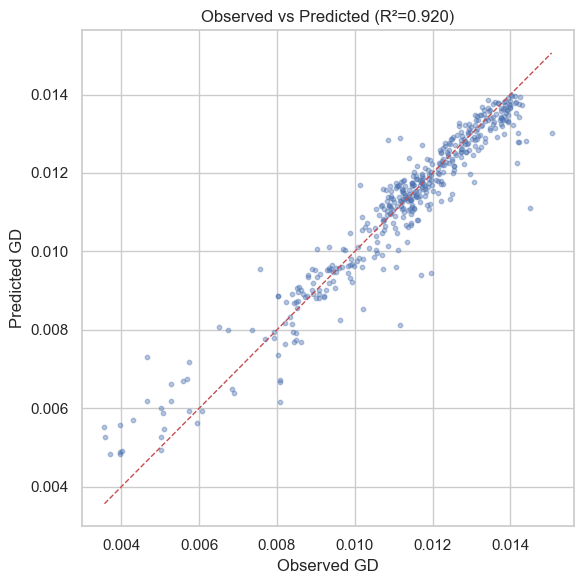

In [33]:
fig, ax = plt.subplots(figsize = (6,6))
ax.scatter(y_test_selected, y_pred, alpha=0.4, s = 10)
lims = [min(y_test_selected.min(), y_pred.min()), max(y_test_selected.max(), y_pred.max())]
ax.plot(lims, lims, 'r--' , linewidth=1)
ax.set_xlabel("Observed GD")
ax.set_ylabel("Predicted GD")
ax.set_title(f"Observed vs Predicted (R²={r2:.3f})")
plt.tight_layout()
plt.show()

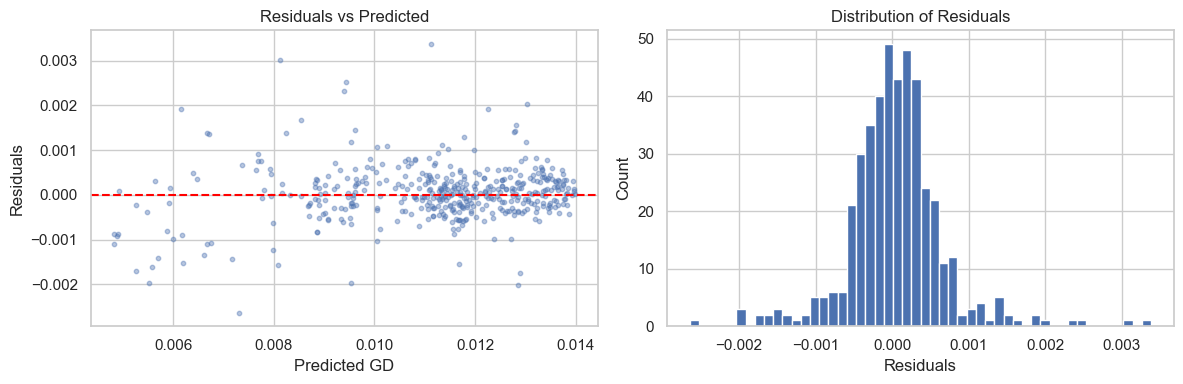

In [34]:
residuals_red = y_test_selected - y_pred

fig, axes = plt.subplots(1,2, figsize = (12,4))

axes[0].scatter(y_pred, residuals_red, alpha=0.4, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Predicted GD")
axes[0].set_ylabel("Residuals") 
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals_red, bins=50, edgecolor='white')
axes[1].set_xlabel("Residuals") 
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.show()

### Feature importance

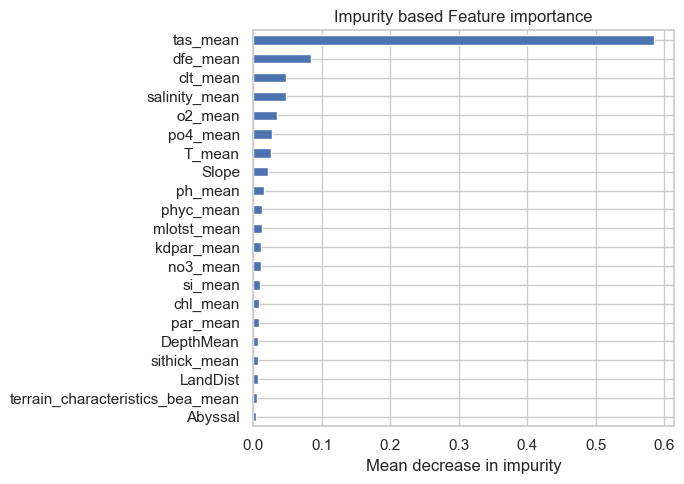

In [35]:
imp_red = pd.Series(rf_selected_RFECV.feature_importances_, index=selected_features_RFECV).sort_values()

fig, ax = plt.subplots(figsize=(7,5))
imp_red.plot.barh(ax=ax)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Impurity based Feature importance")
plt.tight_layout()
plt.show()

## Toekomst

### SSP 1.1.9

In [36]:
toekomst_SSP119 = pd.read_csv("GD_2050-60_SSP119.csv")
X_future = toekomst_SSP119[X_train_selected.columns] #waarom X_train en niet gewoon X?
GD_toekomst = rf_selected_RFECV.predict(X_future)

In [37]:
toekomst_SSP119["GD"] = GD_toekomst
toekomst_SSP119 .head()

,Unnamed: 0,chl_mean,clt_mean,dfe_mean,mlotst_mean,no3_mean,o2_mean,phyc_mean,ph_mean,po4_mean,...,long_deg,lat_deg,DepthMean,LandDist,Slope,Abyssal,par_mean,kdpar_mean,terrain_characteristics_bea_mean,GD
0,0,0.269789,0.689485,0.000391,61.532763,30.799999,314.002378,1.237505,7.970945,2.152274,...,-171.74579,-71.23536,3998,636,730.228795,263.361205,37.450932,0.060146,-3936.972168,0.007011
1,1,0.282911,0.700666,0.000376,63.236088,30.954686,315.845510,1.337427,7.972867,2.166582,...,-167.88679,-71.23536,4079,742,0.000000,993.590000,29.998841,0.062998,-4093.388916,0.006897
2,2,0.270978,0.703526,0.000368,63.562959,30.953779,315.316479,1.259565,7.973096,2.168482,...,-164.02779,-71.23536,4185,708,0.000000,993.590000,32.604841,0.072465,-4160.611328,0.007072
3,3,0.294444,0.697370,0.000348,59.205664,30.785960,318.284476,1.335023,7.976109,2.159415,...,-160.16879,-71.23536,4231,661,0.000000,993.590000,31.006588,0.067391,-4305.361328,0.007111
4,4,0.299291,0.692536,0.000343,60.567262,30.756873,317.223787,1.358980,7.975836,2.158386,...,-156.30979,-71.23536,4322,608,0.000000,993.590000,33.850906,0.066070,-4353.527832,0.007053


Distributie GD

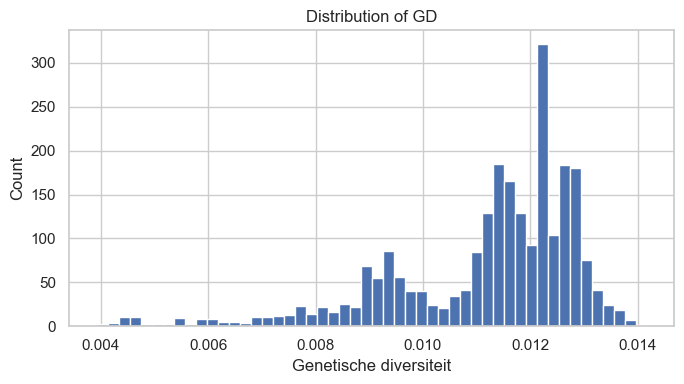

In [38]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(toekomst_SSP119["GD"], bins=50, edgecolor="white")
ax.set_xlabel("Genetische diversiteit")
ax.set_ylabel("Count")
ax.set_title("Distribution of GD")
plt.tight_layout()
plt.show()

Kaart

In [39]:
import plotly.express as px
import plotly.io as pio

In [40]:
fig_SSP119 = px.scatter_geo(
    toekomst_SSP119,
    lat="lat_deg",
    lon="long_deg",
    color="GD",   # kleurt de punten op basis van biodiversiteit
    hover_name="GD",  
    projection="natural earth",    # mooie wereldkaart
    title = "Genetische diversiteit"
)

fig_SSP119.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

### SSP 1.2.6

In [41]:
toekomst_SSP126 = pd.read_csv("GD_2050-60_SSP126.csv")
X_future = toekomst_SSP126[X_train_selected.columns] #waarom X_train en niet gewoon X?
GD_toekomst = rf_selected_RFECV.predict(X_future)

In [42]:
toekomst_SSP126["GD"] = GD_toekomst
toekomst_SSP126 .head()

,Unnamed: 0,chl_mean,clt_mean,dfe_mean,mlotst_mean,no3_mean,o2_mean,phyc_mean,ph_mean,po4_mean,...,long_deg,lat_deg,DepthMean,LandDist,Slope,Abyssal,par_mean,kdpar_mean,terrain_characteristics_bea_mean,GD
0,0,0.264738,0.685382,0.000333,59.873447,30.339450,317.311825,1.462501,7.956235,2.127915,...,-171.74579,-71.23536,3998,636,730.228795,263.361205,37.450932,0.060146,-3936.972168,0.007077
1,1,0.279545,0.698337,0.000307,59.631997,30.320359,319.230605,1.453052,7.957836,2.126779,...,-167.88679,-71.23536,4079,742,0.000000,993.590000,29.998841,0.062998,-4093.388916,0.006803
2,2,0.272520,0.703587,0.000304,52.292932,30.218967,318.271827,1.395905,7.957967,2.119736,...,-164.02779,-71.23536,4185,708,0.000000,993.590000,32.604841,0.072465,-4160.611328,0.006818
3,3,0.297756,0.698612,0.000315,31.966103,29.987898,320.985091,1.454854,7.960676,2.105292,...,-160.16879,-71.23536,4231,661,0.000000,993.590000,31.006588,0.067391,-4305.361328,0.006904
4,4,0.304306,0.693806,0.000356,38.777512,29.912720,319.709665,1.456157,7.960031,2.100458,...,-156.30979,-71.23536,4322,608,0.000000,993.590000,33.850906,0.066070,-4353.527832,0.006906


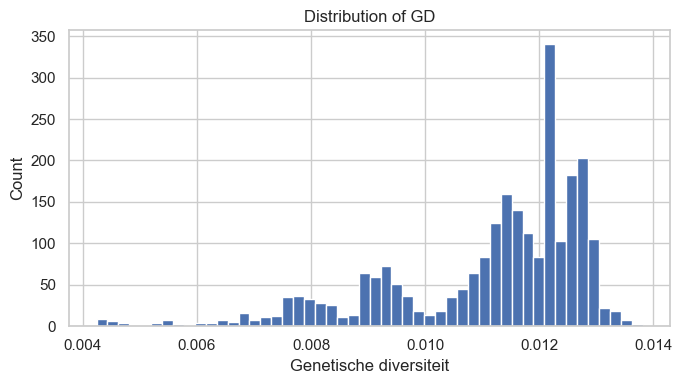

In [43]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(toekomst_SSP126["GD"], bins=50, edgecolor="white")
ax.set_xlabel("Genetische diversiteit")
ax.set_ylabel("Count")
ax.set_title("Distribution of GD")
plt.tight_layout()
plt.show()

In [44]:
fig_SSP126 = px.scatter_geo(
    toekomst_SSP126,
    lat="lat_deg",
    lon="long_deg",
    color="GD",   # kleurt de punten op basis van biodiversiteit
    hover_name="GD",  
    projection="natural earth",    # mooie wereldkaart
    title = "Genetische diversiteit"
)

fig_SSP126.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed